In [144]:
from dotenv import load_dotenv

load_dotenv()

True

In [72]:
import os

os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [142]:
from langchain_openai import ChatOpenAI

In [73]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [74]:
# !uv pip install arxiv
# !uv pip install wikipedia

In [75]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [76]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [77]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [78]:
import wikipedia

# Set a custom user agent to prevent Wikipedia from blocking the request
wikipedia.set_user_agent("MyLangChainApp/1.0 (your_email@example.com)")



In [79]:
wiki.invoke("Tell me About RAg?")

'Page: Tell Me Something Good\nSummary: "Tell Me Something Good" is a song by Rufus included on their 1974 album Rags to Rufus, written by Stevie Wonder and released in 1974. This was the first and only hit credited to Rufus. As singer Chaka Khan\'s voice became the focus of the group, they changed their name to "Rufus featuring Chaka Khan" for their next album. The single was a hit in the United States, peaking at number three on the Billboard Hot 100 and spent one week at number one on the Cash B'

In [182]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    try:
        return a * b
    except :
        return "Invalide input "

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    try:
        return a / b
    except :
        return "Invalide input "

In [183]:
tools = [multiply,add,divide,tavily,arxiv,wiki]

In [184]:
# !uv pip install langchain_groq

In [185]:
from langchain_groq import ChatGroq


In [186]:
llm = ChatOpenAI(model="gpt-4o")#gpt-oss-120b")
llm_with_tools = llm.bind_tools(tools)

In [132]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")  # Use a model known to support tool calling
llm_with_tools = llm.bind_tools(tools)

In [148]:
from pprint import pprint
from langchain_core.messages import AIMessage,HumanMessage
output = llm_with_tools.invoke([HumanMessage(content="what is 2 plus 2")])

In [149]:
output.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'call_RYviVtLDXI5sY1Ryj8Kvmipu',
  'type': 'tool_call'}]

In [90]:
from langgraph.graph import StateGraph,START,END

In [136]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [137]:
from langgraph.prebuilt import ToolNode,tools_condition

In [150]:
def tool_calling_llm(state:State):
    responce = llm_with_tools.invoke(state['messages'])
    return {
        "messages":[responce]
    }
    
    

In [188]:
builder = StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    
)
builder.add_edge("tools","tool_calling_llm")


graph1 = builder.compile()

In [152]:
messages=graph1.invoke({"messages":[HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_ZDty0tnjGFwqQZjgjkGREQJ0)
 Call ID: call_ZDty0tnjGFwqQZjgjkGREQJ0
  Args:
    query: recent AI news March 3rd 2025
  add (call_bzeurk0EBrX2223YxDuJFYRE)
 Call ID: call_bzeurk0EBrX2223YxDuJFYRE
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "March 2025: All AI updates from the past month", "url": "https://sdtimes.com/ai/march-2025-all-ai-updates-from-the-past-month", "content": "Skip to content\n\nSD Times\n\nSD Times\n\nLatest News\n\n# March 2025: All AI updates from the past month\n\nByJenna Barron\n\nSoftware companies are constantly trying to add more and more AI features to their 

# Agent Memory


In [189]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory) 

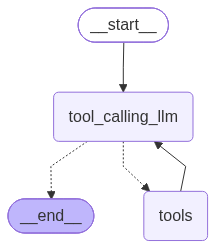

In [190]:
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [191]:
config = {
    "configurable":{'thread_id':'1'}
}
messages = [HumanMessage(content="Add 19 and 21")]

messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 19 and 21
================================== Ai Message ==================================
Tool Calls:
  add (call_g3Lb5mtetq90vHpQO7Yxthw1)
 Call ID: call_g3Lb5mtetq90vHpQO7Yxthw1
  Args:
    a: 19
    b: 21
================================= Tool Message =================================
Name: add

40
================================== Ai Message ==================================

The sum of 19 and 21 is 40.


In [192]:
messages = [HumanMessage(content="divide that number with 0")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 19 and 21
================================== Ai Message ==================================
Tool Calls:
  add (call_g3Lb5mtetq90vHpQO7Yxthw1)
 Call ID: call_g3Lb5mtetq90vHpQO7Yxthw1
  Args:
    a: 19
    b: 21
================================= Tool Message =================================
Name: add

40
================================== Ai Message ==================================

The sum of 19 and 21 is 40.
================================ Human Message =================================

divide that number with 0
================================== Ai Message ==================================
Tool Calls:
  divide (call_UbCyB8twDxlWsfL7hLyJOw7g)
 Call ID: call_UbCyB8twDxlWsfL7hLyJOw7g
  Args:
    a: 40
    b: 0
================================= Tool Message =================================
Name: divide

Invalide input 
================================== Ai Message ==================================

In [187]:
messages = [HumanMessage(content="You are a senior researcher or r&d head on an organization.just remember this do not forgot and just say:'I am Ready'")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_zZEbJnTBAFxLi3cHwPDbkk3c, call_4XdbcH2andcwg17GcUfIMoL0", 'type': 'invalid_request_error', 'param': 'messages.[22].role', 'code': None}}

In [180]:
inu = 1
while inu:
    inu = input("Enter your Question : ")
    if inu == 'exit':
        break
    messages = [HumanMessage(content=inu)]
    messages=graph_memory.invoke({"messages":messages},config=config)
    for m in messages['messages']:
        m.pretty_print()

================================ Human Message =================================

Add 19 and 21
================================== Ai Message ==================================
Tool Calls:
  add (call_GxlzVQD3VIAAyseRtren3rhF)
 Call ID: call_GxlzVQD3VIAAyseRtren3rhF
  Args:
    a: 19
    b: 21
================================= Tool Message =================================
Name: add

40
================================== Ai Message ==================================

The sum of 19 and 21 is 40.
================================ Human Message =================================

add that number with 3
================================== Ai Message ==================================
Tool Calls:
  add (call_1LRA4y6ke8OCWy1ZdncoRKPI)
 Call ID: call_1LRA4y6ke8OCWy1ZdncoRKPI
  Args:
    a: 40
    b: 3
================================= Tool Message =================================
Name: add

43
================================== Ai Message ==================================

Adding 3 to 40 gives

ZeroDivisionError: division by zero